# Ejercicio 2 

En este ejercicio se generaron matrices de Wishart a partir de una matriz aleatoria (D), construyendo $A=DD^{T}$ y $B=D^{T}D$. Se calcularon y compararon numéricamente sus autovalores para matrices con entradas provenientes de una distribución normal y de una distribución exponencial.

Para la distribución normal se verificó que A y B comparten los mismos autovalores no nulos, mientras que la matriz de mayor dimensión presenta autovalores adicionales aproximadamente iguales a cero. Posteriormente, al utilizar una distribución exponencial, se observó la aparición de un autovalor dominante debido principalmente a que los datos tienen media distinta de cero.

## Ejercicio A

In [170]:
import matplotlib.pyplot as plt
import numpy as np

Primero creamos una función que nos genere las matrices $A$ y $B$, donde $A = DD^{T}$ y $B = D^{T}D$. Yo lo hice al revés porque leí mal el ejercicio: $A = D^{T}D$ y $B = DD^{T}$, pero espero que no haya problema porque me di cuenta del error cuando ya había terminado el código. En fin, creamos las matrices de tamaño $N$ y $T$. con ayuda del código de ejercicio 1.

In [171]:
def matriz_wishart(N,T):
    D = np.random.normal(0,1, size = (N,T))
    D_T = D.T
    w_wishart= (D @ D_T) 
    w_wishart_prima = (D_T @ D) 
    return w_wishart, w_wishart_prima


Ahora necesito una función que calcule los autovalores de cada una de las matrices, para ello usamos parte del código del ejercicio 1, con la diferencia de que lo haremos para las 2 matrices.

In [172]:
def obtención_autovalores(N,M):
    autovalores_A = []
    autovalores_B = []
    A, B = matriz_wishart(N,M)
  
    autovalores_A.extend(np.linalg.eigvalsh(A))
    autovalores_B.extend(np.linalg.eigvalsh(B))

    autovalores_A = np.array(autovalores_A)
    autovalores_B = np.array(autovalores_B)

    return autovalores_A , autovalores_B

In [ ]:
autovalores_A, autovalores_B = obtención_autovalores(50,100)

Para visualizar los datos es mejor utilizar plot, ya que si lo ejecuto, no podría ver todos los autovalores de cada matriz, así que es mejor comparar en una gráfica

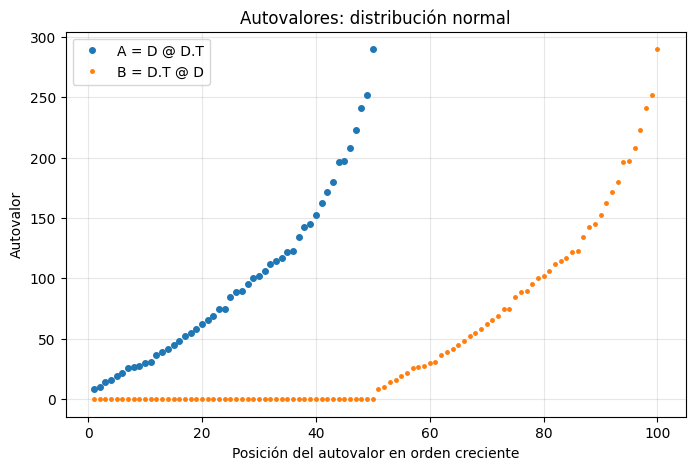

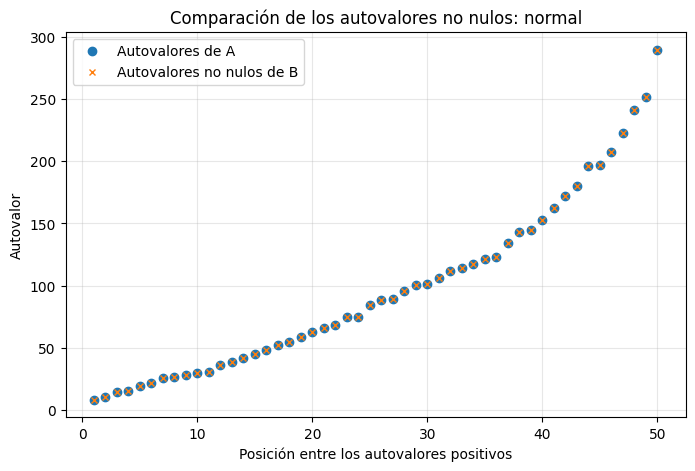

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(
    np.arange(1, 51), np.sort(autovalores_A),
    "o", markersize=4, label="A = D @ D.T"
)

plt.plot(
    np.arange(1, 101), np.sort(autovalores_B),
    ".", markersize=5, label="B = D.T @ D"
)

plt.xlabel("Posición del autovalor en orden creciente")
plt.ylabel("Autovalor")
plt.title("Autovalores: distribución normal")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    np.arange(1, 51), np.sort(autovalores_A),
    "o", markersize=6, label="Autovalores de A"
)

plt.plot(
    np.arange(1, 51), np.sort(autovalores_B)[50:],
    "x", markersize=5, label="Autovalores no nulos de B"
)

plt.xlabel("Posición entre los autovalores positivos")
plt.ylabel("Autovalor")
plt.title("Comparación de los autovalores no nulos: normal")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**(a) Comparación para la distribución normal**

La matriz $A$ tiene dimensiones $50\times50$, mientras que $B$ tiene dimensiones $100\times100$. Ambas son reales, simétricas y semidefinidas positivas; por tanto, sus autovalores son reales y no negativos. Los valores negativos muy próximos a cero que puedan aparecer son consecuencia del redondeo numérico.

La matriz $A$ presenta 50 autovalores positivos, mientras que $B$ tiene 50 autovalores aproximadamente nulos y 50 positivos. Los autovalores positivos de ambas matrices coinciden, salvo las diferencias asociadas a la precisión numérica.

La razón más directa es: Supongamos que $v$ es un autovector de $B=D^TD$ con autovalor $\lambda\neq0$, es decir, $D^TDv=\lambda v$. Multiplicamos por $D$ a la izquierda y obtenemos $DD^TDv=\lambda Dv$. Agrupando, $(DD^T)(Dv)=\lambda(Dv)$. Pero $DD^T=A$, así que $A(Dv)=\lambda(Dv)$. Como $\lambda\neq0$, necesariamente $Dv\neq0$. Por lo tanto, $Dv$ es un autovector de $A$ con el mismo autovalor $\lambda$. 

## Ejercicio B 

Utlizando lo que tenemos anteriormente, generamos la matriz con entradas de distribución exponencial para ello cambiamos la linea de código y listo

In [174]:
def matriz_wishart_exponencial(N,T):
    D = np.random.exponential(scale=1.0, size=(N, T))
    D_T = D.T
    w_wishart= (D @ D_T) 
    w_wishart_prima = (D_T @ D) 
    return w_wishart, w_wishart_prima

In [175]:
def obtención_autovalores_exponencial(N,M):
    autovalores_A = []
    autovalores_B = []
    A, B = matriz_wishart_exponencial(N,M)

        
    autovalores_A.extend(np.linalg.eigvalsh(A))
    autovalores_B.extend(np.linalg.eigvalsh(B))

    autovalores_A = np.array(autovalores_A)
    autovalores_B = np.array(autovalores_B)

    return autovalores_A , autovalores_B

In [ ]:
autovalores_A_exp, autovalores_B_exp = obtención_autovalores_exponencial(50,100)

Generamos la gráfica 

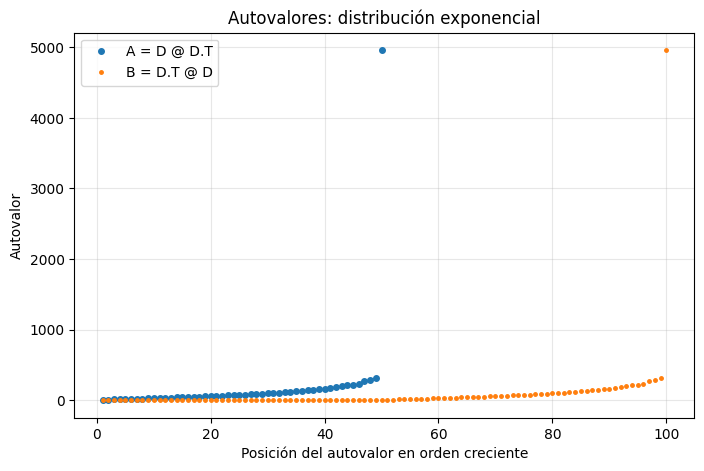

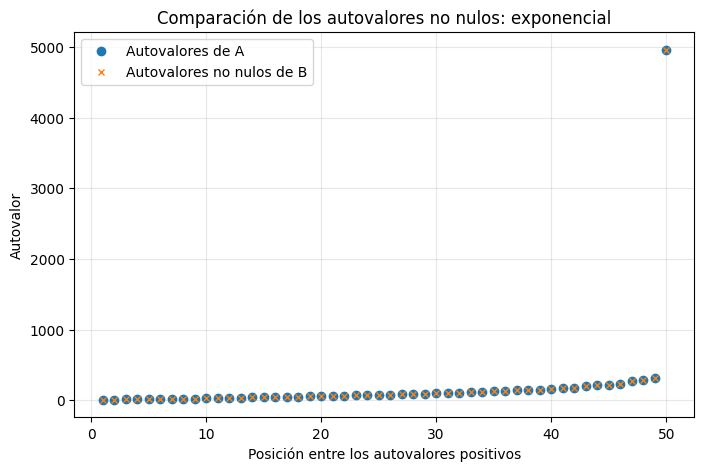

In [179]:
plt.figure(figsize=(8,5))

plt.plot(
    np.arange(1, 51), autovalores_A_exp,
    "o", markersize=4, label="A = D @ D.T"
)

plt.plot(
    np.arange(1, 101), autovalores_B_exp,
    ".", markersize=5, label="B = D.T @ D"
)

plt.xlabel("Posición del autovalor en orden creciente")
plt.ylabel("Autovalor")
plt.title("Autovalores: distribución exponencial")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
plt.figure(figsize=(8,5))

plt.plot(
    np.arange(1, 51), np.sort(autovalores_A_exp),
    "o", markersize=6, label="Autovalores de A"
)

plt.plot(
    np.arange(1, 51), np.sort(autovalores_B_exp)[50:],
    "x", markersize=5, label="Autovalores no nulos de B"
)

plt.xlabel("Posición entre los autovalores positivos")
plt.ylabel("Autovalor")
plt.title("Comparación de los autovalores no nulos: exponencial")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**(b) Comparación para la distribución exponencial**

Se observa una diferencia importante respecto al caso normal: en el caso exponencial aparece un autovalor dominante, considerablemente mayor que los demás. La escala vertical necesaria para representarlo hace que el resto del espectro parezca comprimido cerca del origen, aunque estos autovalores no sean todos nulos.

Las distribuciones utilizadas tienen la misma varianza, igual a 1, pero distintas medias: la normal estándar tiene media 0 y la exponencial tiene media 1. Como los datos no se centraron, la media positiva de la distribución exponencial introduce una contribución común en los productos de datos que favorece la aparición del autovalor dominante.

Las diferencias observadas no pueden atribuirse exclusivamente a la forma de la distribución, pues también interviene el cambio de media.
